In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

In [6]:
end = dt.datetime.today()
start = end - dt.timedelta(days=42*365)
data = yf.download('^GSPC', start=start, end=end, progress=True, interval='3mo')

data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Annual Return'] = data['log_return'].rolling(window=4).sum()

[*********************100%***********************]  1 of 1 completed


In [89]:
rolling_12mo_returns_by_year = data["Annual Return"].squeeze().loc[
    data.index.month == 9
].dropna()

rolling_12mo_returns_by_year = rolling_12mo_returns_by_year.iloc[:-1]

rolling_12mo_returns_by_year.index = rolling_12mo_returns_by_year.index.year
rolling_12mo_returns_by_year.index.name = "Year"

annual_returns = rolling_12mo_returns_by_year.to_frame()

start_portfolio_value = 1000000
tax_rate = 0.20

start_values = []
end_values = []
gains = []
taxable_gains = []
losses = []
cumulative_losses = []
taxes = []

after_tax_log_returns = []

for idx, row in annual_returns.iterrows():
    if idx == annual_returns.index.min():
        start_values.append(start_portfolio_value)
    else:
        start_values.append(end_values[-1])

    if row["Annual Return"] < 0:
        losses.append(start_values[-1] * (np.exp(row["Annual Return"]) - 1))
        cumulative_losses.append(cumulative_losses[-1] + losses[-1]) if cumulative_losses else cumulative_losses.append(losses[-1])
        gains.append(0)
        taxes.append(0)
        taxable_gains.append(0)
        end_values.append(start_values[-1] + losses[-1])
    else:
        losses.append(0)
        gains.append(start_values[-1] * (np.exp(row["Annual Return"]) - 1))
        taxable_gains.append(max(gains[-1] + cumulative_losses[-1], 0)) if cumulative_losses else taxable_gains.append(gains[-1])
        cumulative_losses.append(min(cumulative_losses[-1] + gains[-1], 0)) if cumulative_losses else cumulative_losses.append(0)
        taxes.append(taxable_gains[-1] * tax_rate)
        end_values.append(start_values[-1] + gains[-1] - taxes[-1])
    after_tax_log_returns.append(np.log(end_values[-1] / start_values[-1]))

annual_returns["Start Value"] = start_values
annual_returns["Gain"] = gains
annual_returns["Loss"] = losses
annual_returns["Rolling Loss"] = cumulative_losses
annual_returns["Taxable Gain"] = taxable_gains
annual_returns["Taxes"] = taxes
annual_returns["After Tax Gain"] = [g - t for g, t in zip(gains, taxes)]
annual_returns["End Value"] = end_values

annual_returns["After Tax Return"] = after_tax_log_returns

return_cols = ["Annual Return", "After Tax Return"]
dollar_cols = annual_returns.columns.difference(return_cols)

annual_returns.style.format({
    **{col: "{:.2%}" for col in return_cols},
    **{col: "${:,.2f}" for col in dollar_cols}
})

,Annual Return,Start Value,Gain,Loss,Rolling Loss,Taxable Gain,Taxes,After Tax Gain,End Value,After Tax Return
Year,,,,,,,,,,
1986,20.92%,"$1,000,000.00","$232,724.95",$0.00,$0.00,"$232,724.95","$46,544.99","$186,179.96","$1,186,179.96",17.07%
1987,-7.90%,"$1,186,179.96",$0.00,"$-90,051.05","$-90,051.05",$0.00,$0.00,$0.00,"$1,096,128.91",-7.90%
1988,17.26%,"$1,096,128.91","$206,565.37",$0.00,$0.00,"$116,514.32","$23,302.86","$183,262.50","$1,279,391.42",15.46%
1989,23.44%,"$1,279,391.42","$337,914.41",$0.00,$0.00,"$337,914.41","$67,582.88","$270,331.53","$1,549,722.94",19.17%
1990,-7.12%,"$1,549,722.94",$0.00,"$-106,468.10","$-106,468.10",$0.00,$0.00,$0.00,"$1,443,254.84",-7.12%
1991,15.23%,"$1,443,254.84","$237,392.17",$0.00,$0.00,"$130,924.07","$26,184.81","$211,207.36","$1,654,462.20",13.66%
1992,13.94%,"$1,654,462.20","$247,494.73",$0.00,$0.00,"$247,494.73","$49,498.95","$197,995.78","$1,852,457.98",11.30%
1993,6.82%,"$1,852,457.98","$130,726.38",$0.00,$0.00,"$130,726.38","$26,145.28","$104,581.11","$1,957,039.09",5.49%
1994,-1.77%,"$1,957,039.09",$0.00,"$-34,327.35","$-34,327.35",$0.00,$0.00,$0.00,"$1,922,711.73",-1.77%


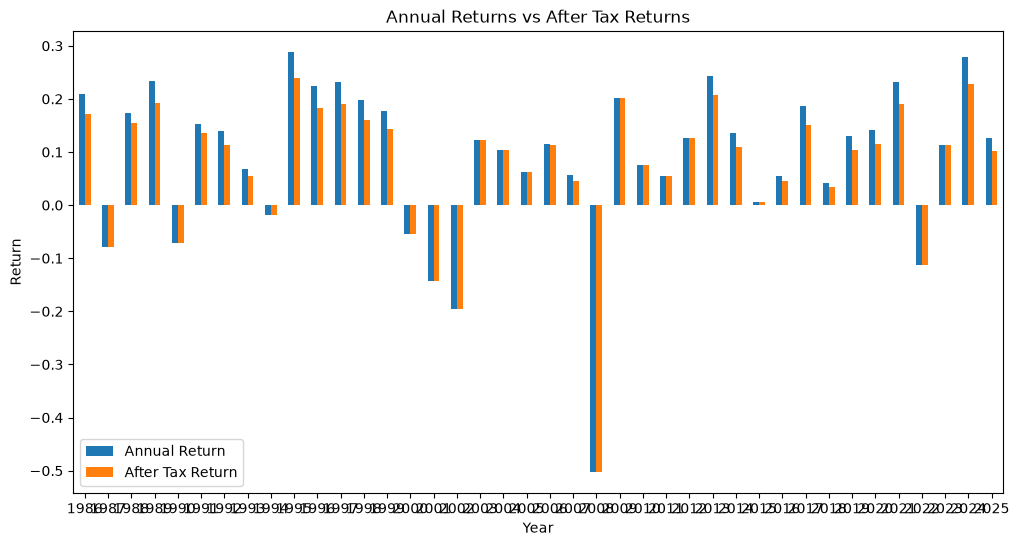

In [84]:
hist = annual_returns[["Annual Return", "After Tax Return"]].plot.bar(
    title="Annual Returns vs After Tax Returns",
    ylabel="Return",
    xlabel="Year",
    figsize=(12, 6),
    rot=0,
    color=["#1f77b4", "#ff7f0e"]
)

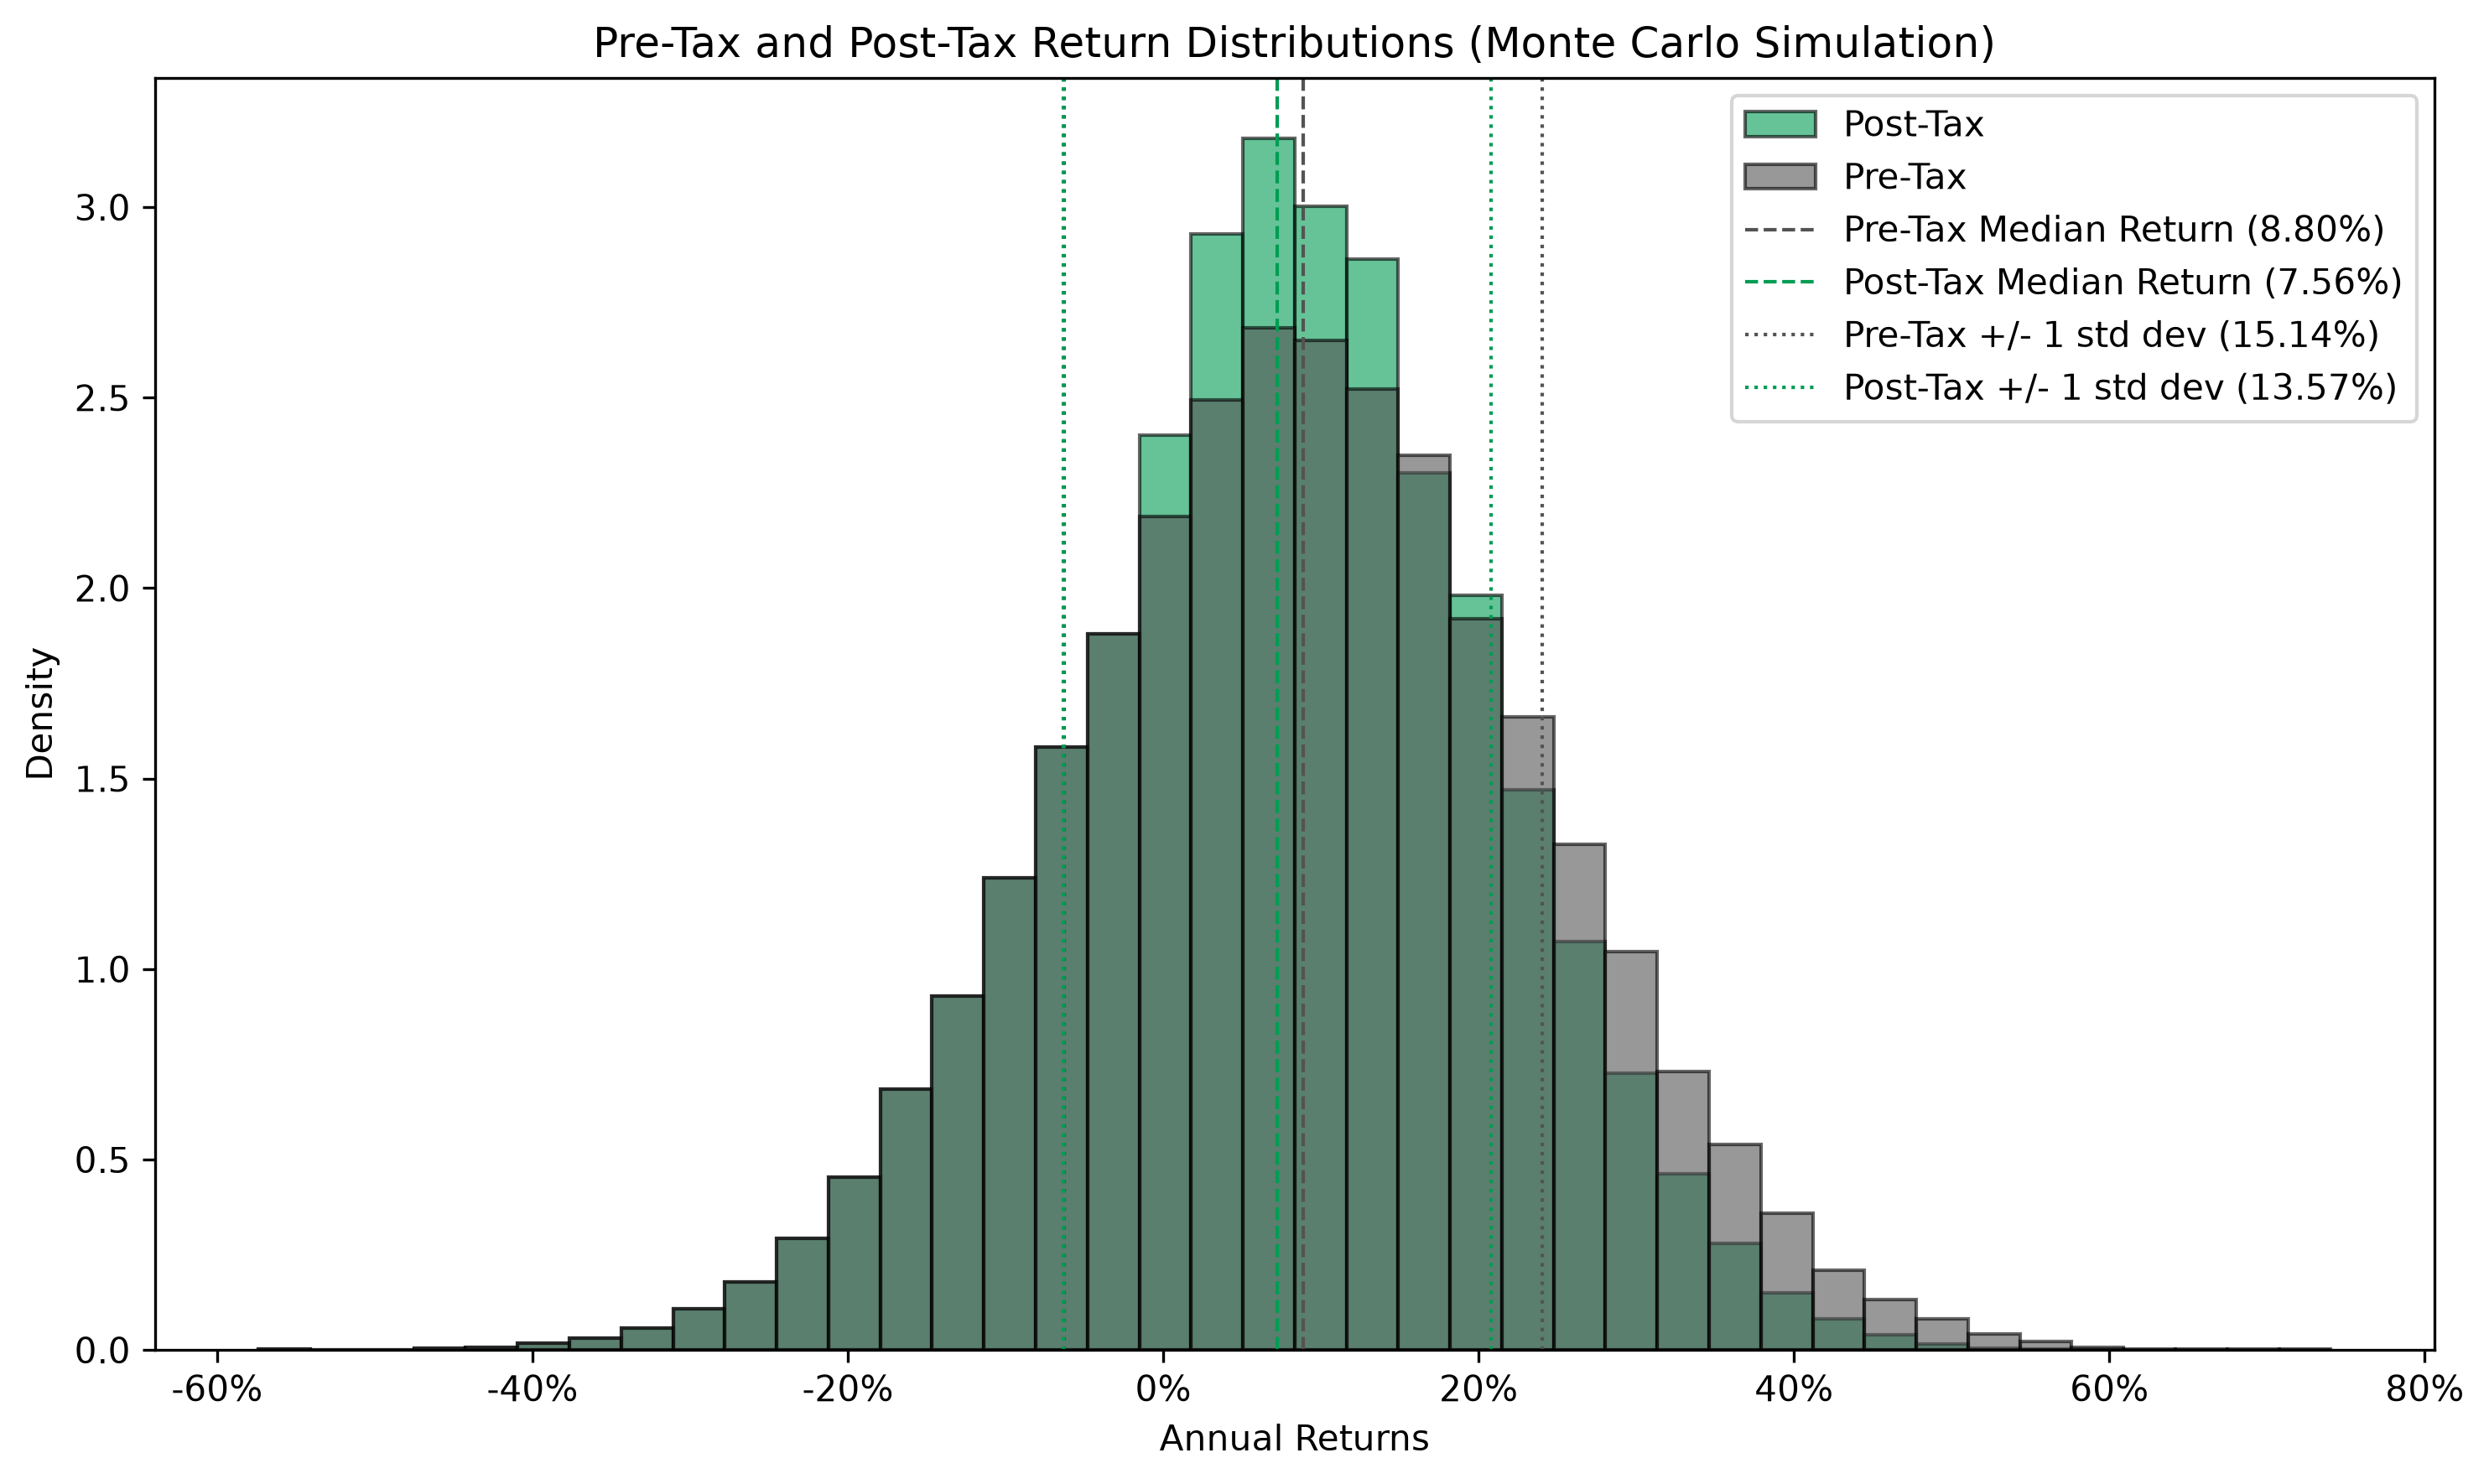

In [96]:
def monte_carlo_tax_simulation(annual_return_series, n_paths=1000, n_years=None,
                                start_portfolio_value=1_000_000, tax_rate=0.20,
                                seed=None):
    """
    Simulate Monte Carlo paths of annual log returns calibrated from the
    historical annual_return_series (mean/std), apply the same tax-loss
    harvesting logic used for annual_returns, and summarize annual samples.
    """
    rng = np.random.default_rng(seed)

    mu = annual_return_series.mean()
    sigma = annual_return_series.std()

    if n_years is None:
        n_years = len(annual_return_series)

    # Simulate log returns: shape (n_paths, n_years)
    simulated_returns = rng.normal(loc=mu, scale=sigma, size=(n_paths, n_years))

    all_after_tax_log_returns = []

    for p in range(n_paths):
        path_returns = simulated_returns[p]

        start_val = start_portfolio_value
        cum_loss = 0.0
        end_val = start_val
        path_after_tax_log_returns = []

        for r in path_returns:
            if r < 0:
                loss = start_val * (np.exp(r) - 1)
                cum_loss += loss
                gain = 0.0
                taxable_gain = 0.0
                tax = 0.0
                end_val = start_val + loss
            else:
                gain = start_val * (np.exp(r) - 1)
                taxable_gain = max(gain + cum_loss, 0.0)
                cum_loss = min(cum_loss + gain, 0.0)
                tax = taxable_gain * tax_rate
                end_val = start_val + gain - tax

            after_tax_log_return = np.log(end_val / start_val)
            path_after_tax_log_returns.append(after_tax_log_return)

            start_val = end_val

        all_after_tax_log_returns.append(path_after_tax_log_returns)

    all_after_tax_log_returns = np.array(all_after_tax_log_returns)

    summary = pd.DataFrame({
        "Pretax Annual Log Return": simulated_returns.ravel(),
        "Posttax Annual Log Return": all_after_tax_log_returns.ravel(),
    })

    stats_summary = summary.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    bin_edges = np.histogram_bin_edges(
        np.concatenate([summary["Pretax Annual Log Return"], summary["Posttax Annual Log Return"]]),
        bins=40,
    )

    ax.hist(
        summary["Posttax Annual Log Return"],
        bins=bin_edges,
        density=True,
        alpha=0.6,
        color="#009C53",
        edgecolor="black",
        label="Post-Tax",
    )
    ax.hist(
        summary["Pretax Annual Log Return"],
        bins=bin_edges,
        density=True,
        alpha=0.6,
        color="#535353",
        edgecolor="black",
        label="Pre-Tax",
    )

    pretax_mean = summary["Pretax Annual Log Return"].mean()
    pretax_std = summary["Pretax Annual Log Return"].std()
    pretax_median = summary["Pretax Annual Log Return"].median()
    posttax_mean = summary["Posttax Annual Log Return"].mean()
    posttax_std = summary["Posttax Annual Log Return"].std()
    posttax_median = summary["Posttax Annual Log Return"].median()

    ax.axvline(pretax_mean, color="#535353", linestyle="--", linewidth=1, label=f"Pre-Tax Median Return ({pretax_median:.2%})")
    ax.axvline(posttax_mean, color="#009C53", linestyle="--", linewidth=1, label=f"Post-Tax Median Return ({posttax_median:.2%})")
    ax.axvline(
        pretax_mean - pretax_std,
        color="#535353",
        linestyle=":",
        linewidth=1,
        label=f"Pre-Tax +/- 1 std dev ({pretax_std:.2%})",
    )
    ax.axvline(pretax_mean + pretax_std, color="#535353", linestyle=":", linewidth=1)
    ax.axvline(
        posttax_mean - posttax_std,
        color="#009C53",
        linestyle=":",
        linewidth=1,
        label=f"Post-Tax +/- 1 std dev ({posttax_std:.2%})",
    )
    ax.axvline(posttax_mean + posttax_std, color="#009C53", linestyle=":", linewidth=1)

    ax.set_title("Pre-Tax and Post-Tax Return Distributions (Monte Carlo Simulation)")
    ax.set_xlabel("Annual Returns")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_ylabel("Density")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return summary, stats_summary, simulated_returns, all_after_tax_log_returns


mc_summary, mc_stats, mc_simulated_returns, mc_after_tax_paths = monte_carlo_tax_simulation(
    annual_return_series=annual_returns["Annual Return"],
    n_paths=1000,
    n_years=len(annual_returns),
    start_portfolio_value=start_portfolio_value,
    tax_rate=tax_rate,
    seed=42
)

#print(mc_stats)

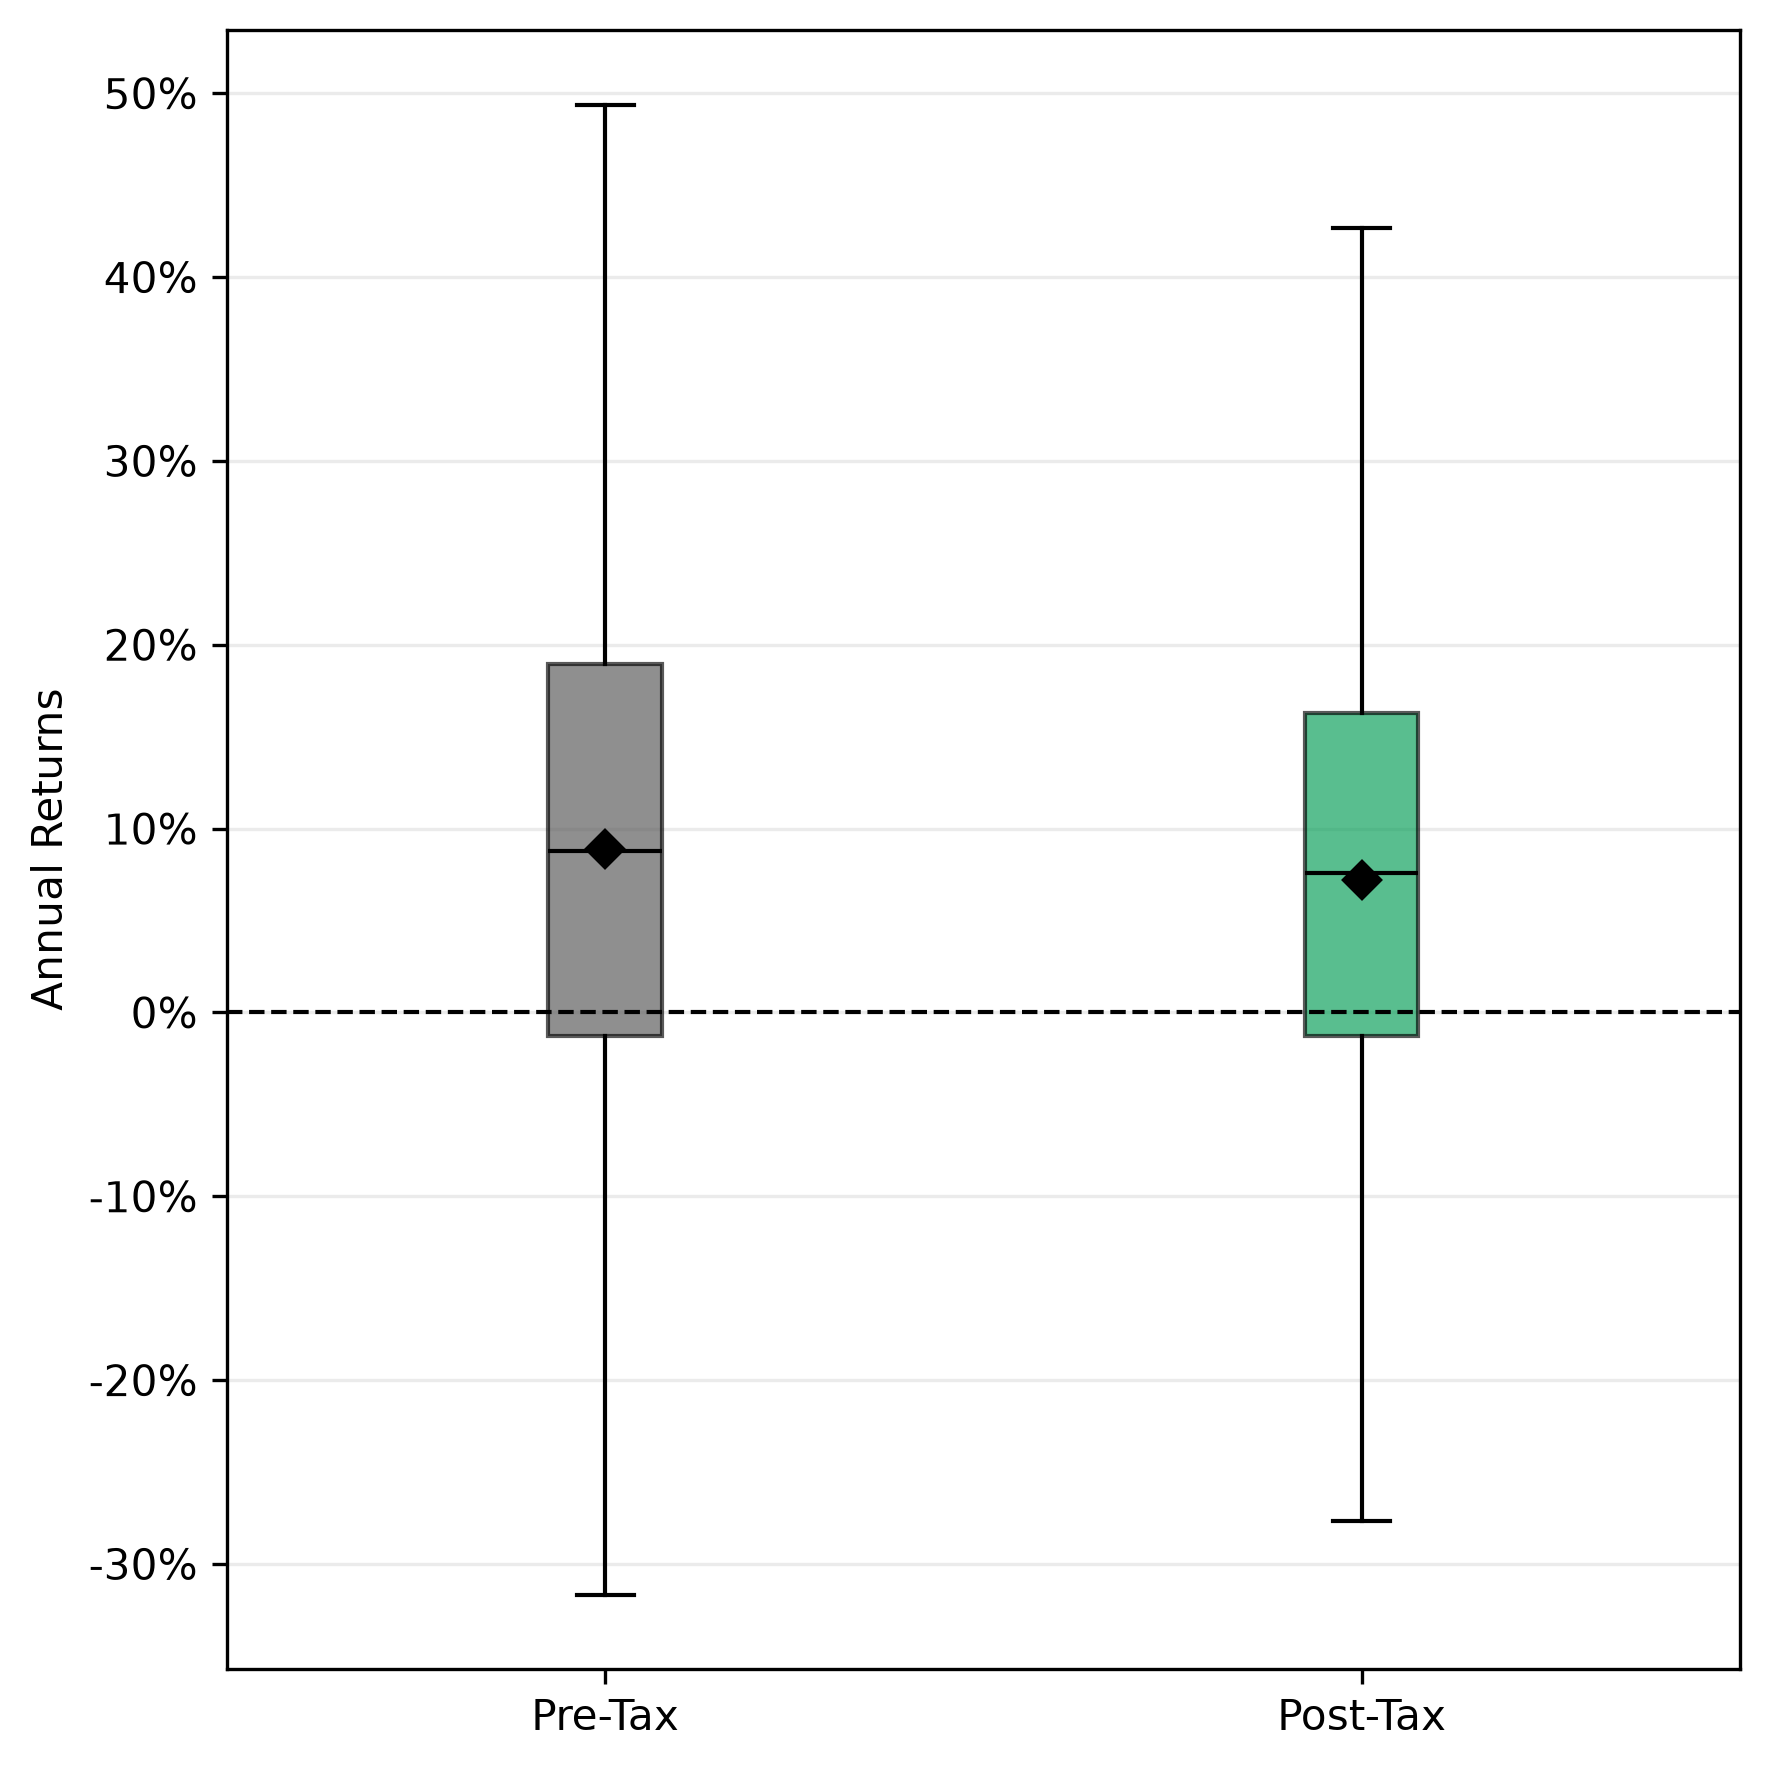

In [99]:
comparison_stats = mc_summary.agg(["mean", "std"]).T
comparison_stats.index = ["Pretax", "Posttax"]

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
box_plot = ax.boxplot(
    [mc_summary["Pretax Annual Log Return"], mc_summary["Posttax Annual Log Return"]],
    tick_labels=["Pre-Tax", "Post-Tax"],
    patch_artist=True,
    showmeans=True,
    showfliers=False,
    boxprops={"linewidth": 1},
    medianprops={"color": "black", "linewidth": 1},
    whiskerprops={"linewidth": 1},
    capprops={"linewidth": 1},
    meanprops={"marker": "D", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 6},
)

for box, color in zip(box_plot["boxes"], ["#535353", "#009C53"]):
    box.set_facecolor(color)
    box.set_alpha(0.65)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("Annual Returns")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
#ax.set_title("Pre-Tax and Post-Tax Return Distributions (Monte Carlo Simulation)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

#print(comparison_stats.rename(columns={"mean": "Mean", "std": "Standard Deviation"}))

In [65]:
mc_simulated_returns_df = pd.DataFrame(mc_simulated_returns, columns=annual_returns.index)
mc_simulated_returns_df.head()

Year,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,0.134049,-0.066199,0.200426,0.228737,-0.201870,-0.105245,0.107709,0.041578,0.086169,-0.038361,...,0.028149,0.012390,-0.032513,0.180401,0.256794,0.071703,-0.036442,-0.034108,0.185555,0.199354
1,0.169556,-0.010434,0.123244,0.106048,0.121238,0.218441,0.121968,0.189773,0.098735,0.131726,...,-0.048250,0.162707,0.109881,0.191496,0.025046,0.112280,0.181832,0.042604,0.156693,-0.009900
2,0.034607,0.031824,-0.089409,0.161189,0.018770,0.090532,0.160262,0.155167,0.187758,0.074005,...,-0.126670,0.099412,0.009821,0.123320,0.091925,0.327202,0.053027,-0.063744,0.115368,0.121432
3,0.291076,0.213033,0.141815,0.306581,-0.088355,-0.006598,-0.049311,0.030622,-0.116340,0.183256,...,0.080662,0.351945,0.108071,0.235017,0.014318,-0.087786,-0.055050,-0.019327,0.405635,-0.033647
4,0.213536,-0.045789,0.227398,0.145997,0.065345,0.082601,-0.008837,0.155099,0.020917,-0.093842,...,-0.044568,0.184473,0.029908,0.087908,0.064332,0.138942,0.298268,0.102161,0.184564,-0.216633


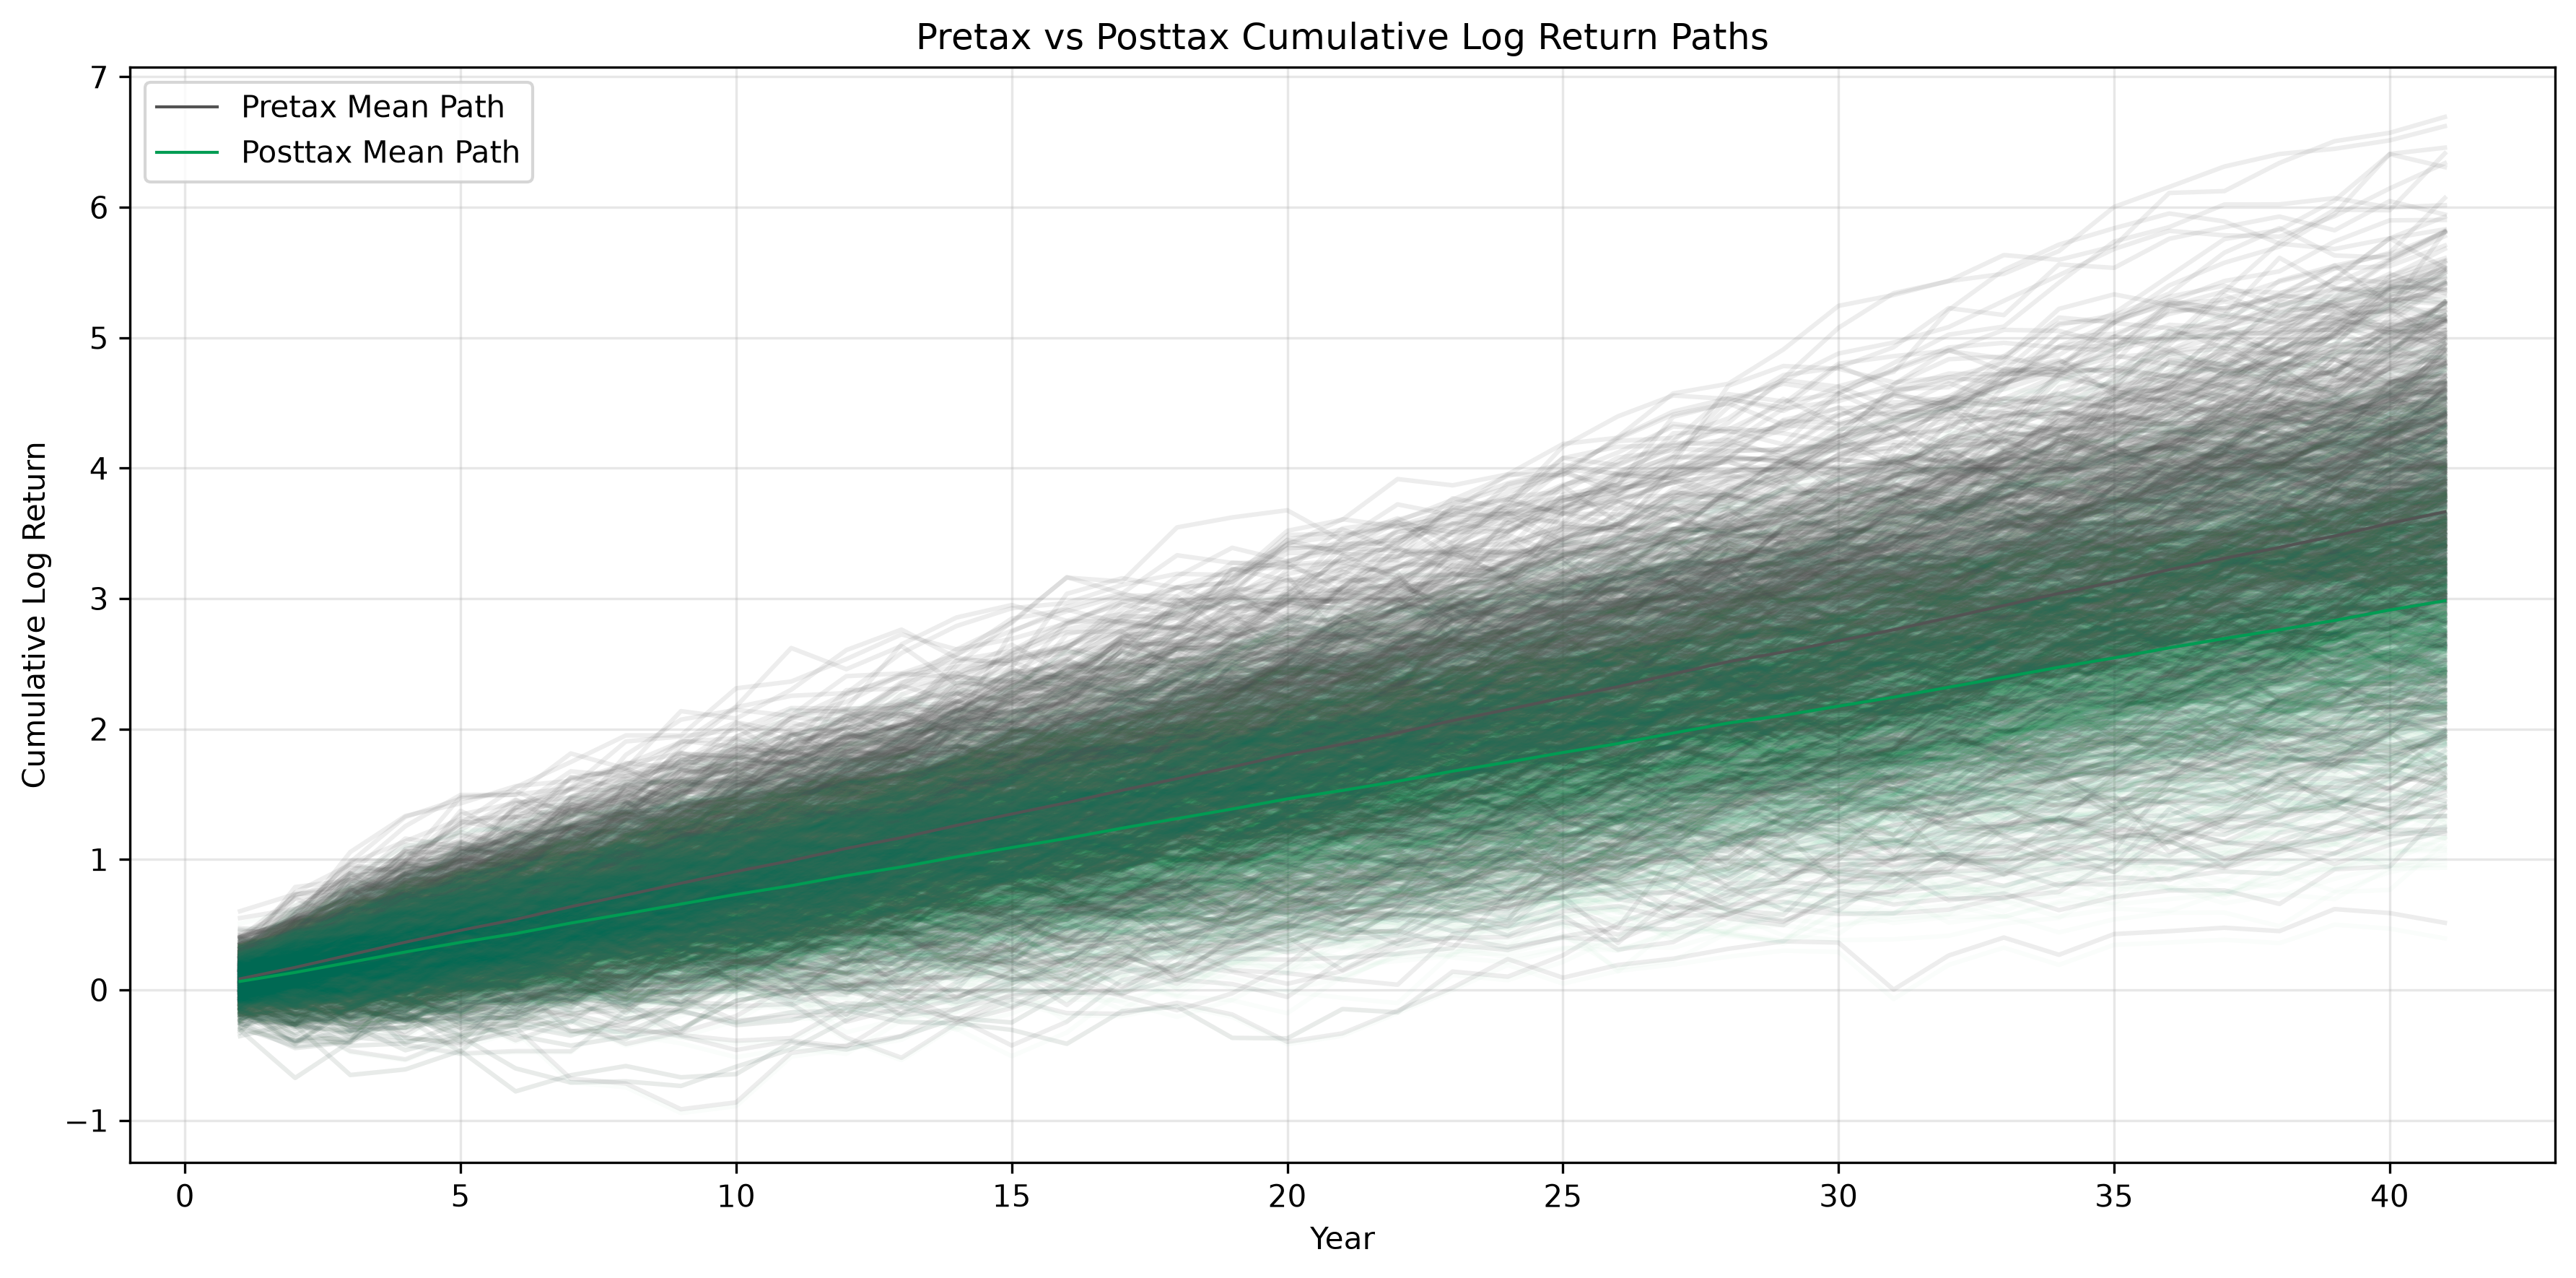

In [66]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

years = np.arange(1, mc_simulated_returns.shape[1] + 1)
pretax_cum_returns = mc_simulated_returns.cumsum(axis=1)
posttax_cum_returns = mc_after_tax_paths.cumsum(axis=1)

rng = np.random.default_rng(42)
sampled_paths = rng.choice(pretax_cum_returns.shape[0], size=pretax_cum_returns.shape[0] // 5, replace=False)
path_alphas = np.linspace(0.03, 0.25, len(sampled_paths))

for path_idx, alpha in zip(sampled_paths, path_alphas):
    ax.plot(years, pretax_cum_returns[path_idx], color="#535353", alpha=alpha, linewidth=0.8)
    ax.plot(years, posttax_cum_returns[path_idx], color="#009C53", alpha=alpha, linewidth=0.8)

ax.plot(years, pretax_cum_returns.mean(axis=0), color="#535353", linewidth=2, label="Pretax Mean Path")
ax.plot(years, posttax_cum_returns.mean(axis=0), color="#009C53", linewidth=2, label="Posttax Mean Path")

ax.set_title("Pretax vs Posttax Cumulative Log Return Paths")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Log Return")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()